In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

### Load the dataset

In [3]:
adata = se.load_h5ad("data/exp_1.h5ad")
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("results/phenotyping_annotations.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["annotation", "annotation_level2"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

#### Define image path

In [5]:
image_path = "background/OnTIMEr18_n_a_backsub.ome.tif"

### Use SCIMAP gate_finder function to define the gating value for each channel

In [6]:
marker_of_interest = 'CD45'

In [7]:
# Use the default data matrix (adata.X) by not specifying a non-existent layer.
# If you want to use a specific layer, set layer to that layer name (must exist in adata.layers).
sm.pl.gate_finder(image_path, 
                  adata, 
                  marker_of_interest, 
                  layer="raw",
                  log=True,
                  from_gate=6, 
                  to_gate=10, 
                  increment=0.1, 
                  point_size=6)

/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_89070/1345550918.py:3: FutureWarning:

gate_finder() is deprecated and will be removed in a future version. Please use sm.pl.napariGater() instead.



In [6]:
# Load the manual gates from CSV and rescale the data based on the gates
manual_gate = pd.read_csv('data/manual_gates.csv')
manual_gate

,markers,exp
0,IGFBP5,8.5
1,COL4A1,9.0
2,CD146,7.1
3,RS6,8.8
4,CD31,7.0
5,Vimentin,7.5
6,CD68,9.0
7,CD19,10.0
8,PCK,7.4
9,CD3,8.0


In [7]:
adata = sm.pp.rescale (adata, 
                       gate=manual_gate,
                       imageid='imageid',
                       )

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/preprocessing/rescale.py:145: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Running GMM for image: exp
Applying GMM to markers: DNA_1, COL1A1

Scaling Image: exp
Scaling DNA_1 (gate: 10.060)
Scaling IGFBP5 (gate: 8.500)
Scaling COL4A1 (gate: 9.000)
Scaling CD146 (gate: 7.100)
Scaling RS6 (gate: 8.800)
Scaling CD31 (gate: 7.000)
Scaling Vimentin (gate: 7.500)
Scaling CD68 (gate: 9.000)
Scaling CD19 (gate: 10.000)
Scaling PCK (gate: 7.400)
Scaling CD3 (gate: 8.000)
Scaling NaKATPase (gate: 9.000)
Scaling COL1A1 (gate: 2.545)
Scaling CD90 (gate: 7.500)
Scaling PDPN (gate: 8.500)
Scaling CK19 (gate: 6.000)
Scaling Tenascin (gate: 9.200)
Scaling COL6A1 (gate: 9.000)
Scaling SMA (gate: 8.400)
Scaling FN (gate: 8.800)
Scaling CD45 (gate: 8.100)
Scaling HLADR (gate: 8.400)
Scaling CD11c (gate: 8.800)
Scaling CD4 (gate: 8.000)
Scaling CD14 (gate: 8.800)


### Subset immune cells 

In [8]:
immune_cells = se.subset_cells(
    adata,
    "annotation_level2",
    "stroma-immune"
)

In [9]:
# load the phenotyping workflow
phenotype = pd.read_csv('data/immune_phenotype_workflow.csv')
# view the table:
phenotype.style.format(na_rep='')

,Unnamed: 0,Unnamed: 1,COL4A1,Vimentin,CD68,PCK,CD3,NaKATPase,CD90,PDPN,Tenascin,COL6A1,SMA,FN,CD45,HLADR,CD11c,CD4,CD14
0,all,other immune cells,,,anypos,,anypos,,,,,,,,anypos,,anypos,,anypos
1,other immune cells,T cells,,,,,pos,,,,,,,,,,,,
2,other immune cells,Myeloid Lineage,,,anypos,,,,,,,,,,,,anypos,,anypos
3,T cells,CD4 T cells,,,,,,,,,,,,,,,,pos,
4,Myeloid Lineage,Macrophages,,,pos,,,,,,,,,,,,,,
5,Myeloid Lineage,Monocytes,,,,,,,,,,,,,,,,,pos
6,Myeloid Lineage,Dendritic cells,,,,,,,,,,,,,,,pos,,


In [10]:
immune_cells = sm.tl.phenotype_cells (immune_cells, 
                                      phenotype=phenotype, 
                                      label="immune_phenotype") 

Phenotyping other immune cells
-- Subsetting other immune cells
Phenotyping T cells
Phenotyping Myeloid Lineage
-- Subsetting T cells
Phenotyping CD4 T cells
-- Subsetting Myeloid Lineage
Phenotyping Macrophages
Phenotyping Monocytes
Phenotyping Dendritic cells
Consolidating the phenotypes across all groups


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [11]:
# Summary of the phenotyping
immune_cells.obs['immune_phenotype'].value_counts()

immune_phenotype
other immune cells    4659
Unknown               3596
CD4 T cells           1926
Monocytes             1047
T cells                755
Macrophages            493
Dendritic cells        171
Name: count, dtype: int64

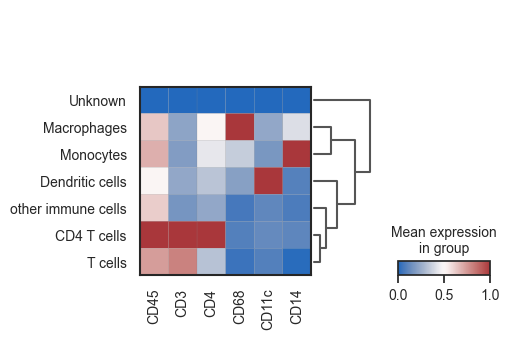

In [12]:
# Ensure the groupby column is categorical
immune_cells.obs["immune_phenotype"] = immune_cells.obs["immune_phenotype"].astype("category")

# Compute the dendrogram
sc.tl.dendrogram(immune_cells, groupby='immune_phenotype')

# Plot the matrixplot
sc.pl.matrixplot(immune_cells, 
                 var_names=["CD45", "CD3", "CD4",
                            "CD68", "CD11c", "CD14"], 
                 groupby='immune_phenotype', 
                 dendrogram=True, 
                 use_raw=False, 
                 cmap="vlag", 
                 standard_scale='var',
                 )

In [15]:
# Visualize the image with the annotated clusters
sm.pl.image_viewer(image_path=image_path, 
                   adata=immune_cells, 
                   overlay='immune_phenotype', 
                   point_size=6,
                   point_color='white')

### Subset fibroblasts

In [13]:
fibroblasts = se.subset_cells(
    adata,
    "annotation_level2",
    "stroma-fib"
)

In [14]:
# load the phenotyping workflow
phenotype = pd.read_csv('data/fibroblast_phenotype_workflow.csv')
# view the table:
phenotype.style.format(na_rep='')

,Unnamed: 0,Unnamed: 1,COL4A1,Vimentin,CD68,PCK,CD3,NaKATPase,CD90,PDPN,Tenascin,COL6A1,SMA,FN,CD45,HLADR,CD11c,CD4,CD14
0,all,Endothelial cells,anypos,,,,,,,,,,,,,,,,
1,all,myCAFs,neg,,,,,,,,,,pos,,,,,,
2,all,PDPN+ CAFs,neg,,,,,,,pos,,,,,,,,,
3,all,CD90+ CAFs,neg,,,,,,pos,,,,,,,,,,


In [15]:
fibroblasts = sm.tl.phenotype_cells (fibroblasts, 
                                     phenotype=phenotype, 
                                     label="fibroblast_phenotype") 

Phenotyping Endothelial cells
Phenotyping myCAFs
Phenotyping PDPN+ CAFs
Phenotyping CD90+ CAFs
Consolidating the phenotypes across all groups


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [16]:
# Summary of the phenotyping
fibroblasts.obs['fibroblast_phenotype'].value_counts()

fibroblast_phenotype
myCAFs        5590
PDPN+ CAFs     850
Unknown        285
CD90+ CAFs     230
Name: count, dtype: int64

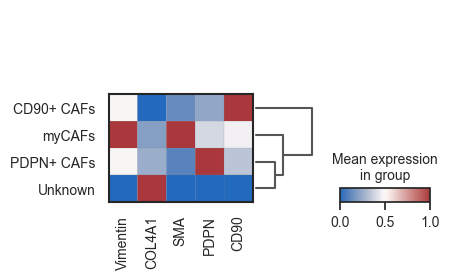

In [17]:
# Ensure the groupby column is categorical
fibroblasts.obs["fibroblast_phenotype"] = fibroblasts.obs["fibroblast_phenotype"].astype("category")

# Compute the dendrogram
sc.tl.dendrogram(fibroblasts, groupby='fibroblast_phenotype')

# Plot the matrixplot
sc.pl.matrixplot(fibroblasts, 
                 var_names=["Vimentin", "COL4A1",
                            "SMA", "PDPN", "CD90"], 
                 groupby='fibroblast_phenotype', 
                 dendrogram=True, 
                 use_raw=False, 
                 cmap="vlag", 
                 standard_scale='var',
                 )

In [21]:
# Visualize the image with the annotated clusters
sm.pl.image_viewer(image_path=image_path, 
                   adata=fibroblasts, 
                   overlay='fibroblast_phenotype', 
                   point_size=6,
                   point_color='white')

### Merge the annotation back

In [18]:
adata.obs["annotated_clusters_update3"] = adata.obs["annotation_level2"].astype(str)

adata.obs.loc[
    immune_cells.obs.index,
    "annotated_clusters_update3"
] = immune_cells.obs["immune_phenotype"].astype(str)

adata.obs.loc[
    fibroblasts.obs.index,
    "annotated_clusters_update3"
] = fibroblasts.obs["fibroblast_phenotype"].astype(str)

In [19]:
# Check the result
print(adata.obs["annotated_clusters_update3"].value_counts())

annotated_clusters_update3
tumour                25827
myCAFs                 5590
other immune cells     4659
Unknown                3881
noise                  3343
vessel                 3160
CD4 T cells            1926
Monocytes              1047
PDPN+ CAFs              850
T cells                 755
Macrophages             493
CD90+ CAFs              230
Dendritic cells         171
Name: count, dtype: int64


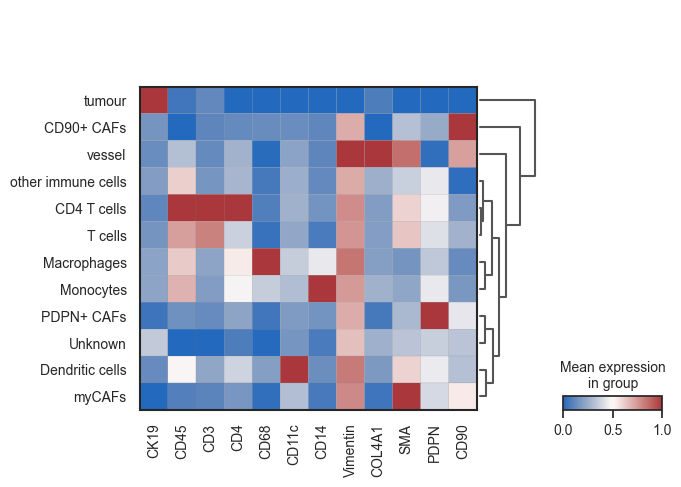

In [20]:
# Remove unwanted clusters
exclude = ["noise"]
adata_heatmap = adata[~adata.obs["annotated_clusters_update3"].isin(exclude)].copy()

# Ensure the groupby column is categorical
adata_heatmap.obs["annotated_clusters_update3"] = adata_heatmap.obs["annotated_clusters_update3"].astype("category")

# Compute the dendrogram
sc.tl.dendrogram(adata_heatmap, groupby='annotated_clusters_update3')

# Plot the matrixplot
sc.pl.matrixplot(adata_heatmap, 
                 var_names=["CK19","CD45",
                            "CD3", "CD4", "CD68", "CD11c", "CD14",
                            "Vimentin", "COL4A1",
                            "SMA", "PDPN", "CD90"], 
                 groupby='annotated_clusters_update3', 
                 dendrogram=True, 
                 use_raw=False, 
                 cmap="vlag", 
                 standard_scale='var',
                 )

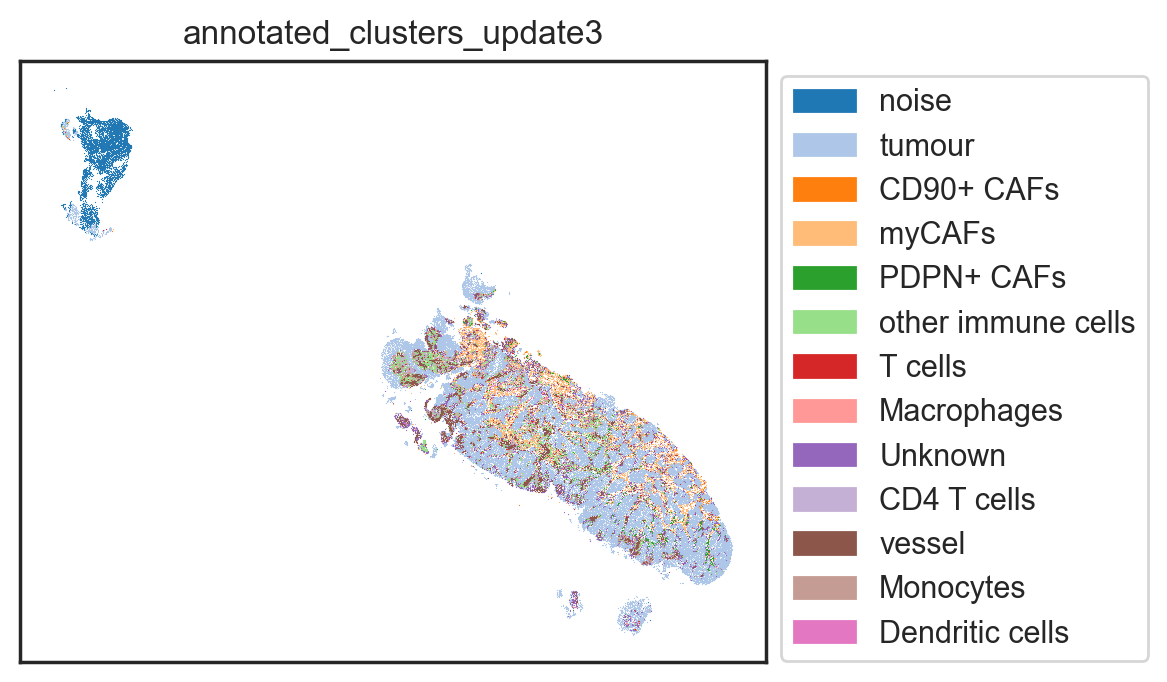

In [21]:
se.spatial_scatter_plot(
    adata,
    colorBy="annotated_clusters_update3",
    x_coordinate="X_centroid",
    y_coordinate="Y_centroid",
    figsize=(6,6)
)

In [ ]:
# Visualize the image with the annotated clusters
sm.pl.image_viewer(image_path=image_path, 
                   adata=adata, 
                   overlay='annotated_clusters_update3', 
                   point_size=6,
                   point_color='white')

save the annotation

In [22]:
adata.obs[
    ["annotation","annotation_level2","annotated_clusters_update3"]
].to_csv(
    "results/phenotyping_annotations.csv"
)